# Impprting librabries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data

In [2]:
data=pd.read_csv('hypertension_dataset.csv')
data.head(10)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
5,20,10.8,3,Hypertension,5.2,21.9,Beta Blocker,Yes,High,Non-Smoker,Yes
6,39,8.9,0,Normal,7.8,27.6,Beta Blocker,Yes,High,Non-Smoker,No
7,70,5.9,1,Hypertension,7.2,25.8,NaN,No,Moderate,Non-Smoker,Yes
8,19,9.3,7,Normal,4.7,36.5,Beta Blocker,Yes,Low,Smoker,Yes
9,47,7.2,5,Normal,6.2,24.3,NaN,No,High,Non-Smoker,No


In [3]:
print("Shape:", data.shape)

Shape: (1985, 11)


In [4]:
print("Columns:", data.columns)

Columns: Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')


# Data Cleaning

# 1. Checking missing values

In [5]:
data.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

In [6]:
data["Medication"] = data["Medication"].fillna(
    data["Medication"].mode()[0]
)
data.isnull().sum()

Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

# 2. Convert categorical to numeric

In [7]:
data = pd.get_dummies(data, drop_first=True)
data

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,BP_History_Normal,BP_History_Prehypertension,Medication_Beta Blocker,Medication_Diuretic,Medication_Other,Family_History_Yes,Exercise_Level_Low,Exercise_Level_Moderate,Smoking_Status_Smoker,Has_Hypertension_Yes
0,69,8.0,9,6.4,25.8,True,False,True,False,False,True,True,False,False,True
1,32,11.7,10,5.4,23.4,True,False,True,False,False,False,True,False,False,False
2,78,9.5,3,7.1,18.7,True,False,True,False,False,False,False,True,False,False
3,38,10.0,10,4.2,22.1,False,False,False,False,False,False,True,False,False,True
4,41,9.8,1,5.8,16.2,False,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,6.5,25.0,True,False,False,True,False,True,True,False,False,True
1981,29,8.9,4,6.9,16.9,False,False,True,False,False,True,False,False,False,True
1982,64,5.9,9,5.6,18.9,True,False,False,False,False,True,False,True,False,True
1983,35,7.4,8,8.2,29.2,False,True,True,False,False,True,False,True,False,False


# Exploratory Data Anaylsis (EDA)

# Target Variable Distribution

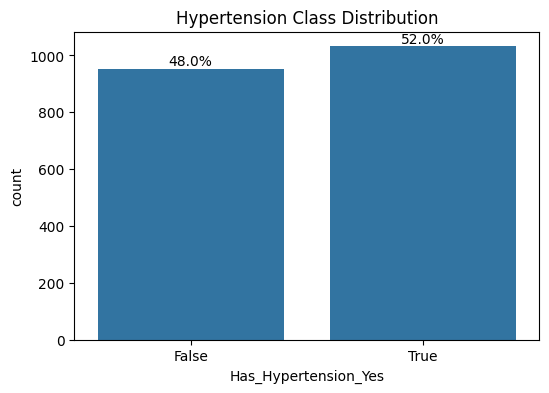

In [8]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=data.iloc[:,-1])
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), 
                ha='center', va='bottom')
plt.title("Hypertension Class Distribution")
plt.show()


# Age Distribution

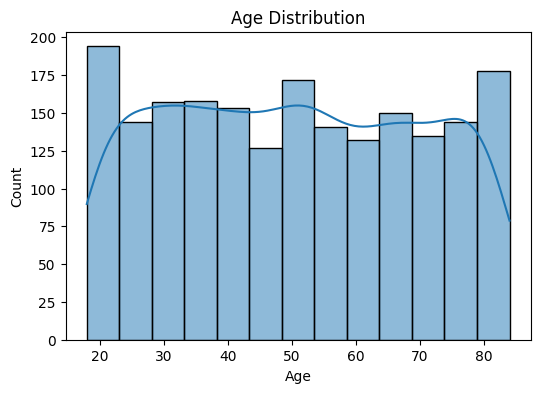

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(data["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


# BMI Distribution

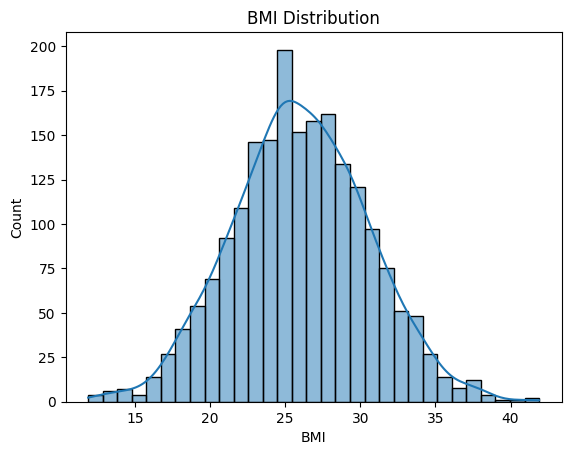

In [10]:
sns.histplot(data["BMI"], kde=True)
plt.title("BMI Distribution")
plt.show()


# Age vs Hypertension

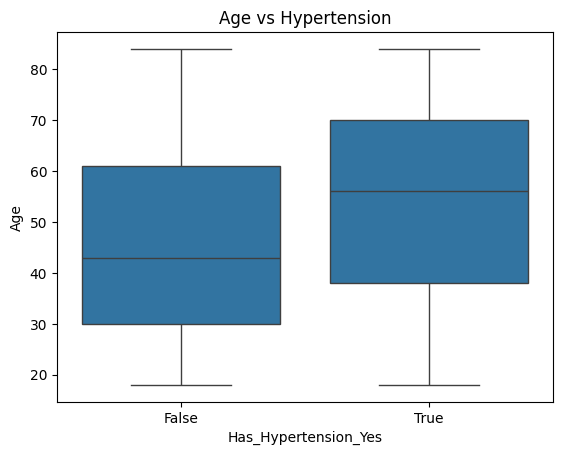

In [11]:
sns.boxplot(x=data.iloc[:,-1], y=data["Age"])
plt.title("Age vs Hypertension")
plt.show()


# BMI vs Hypertension

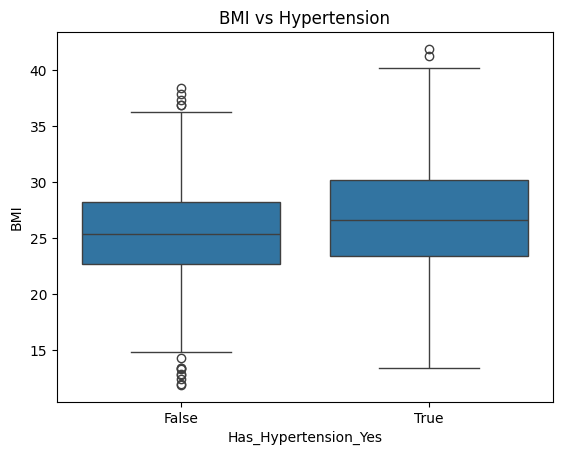

In [12]:
sns.boxplot(x=data.iloc[:,-1], y=data["BMI"])
plt.title("BMI vs Hypertension")
plt.show()


# Correlation Heatmap

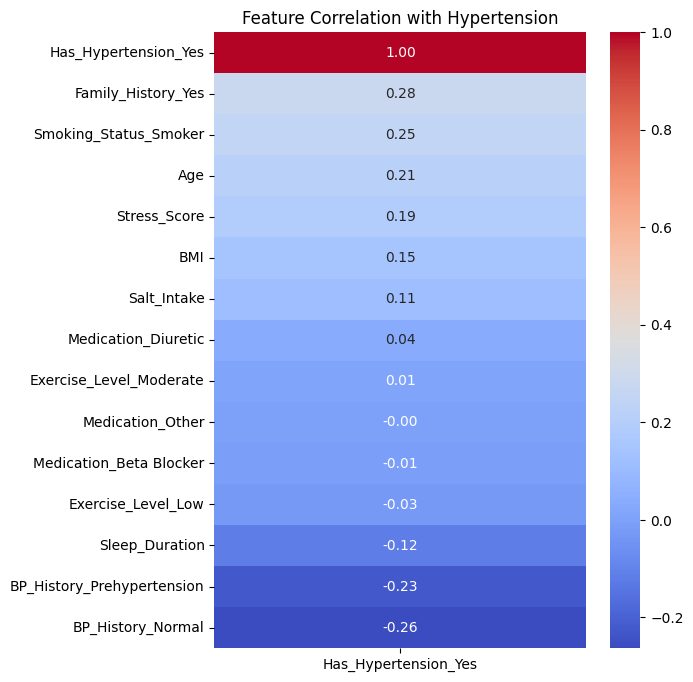

In [13]:
plt.figure(figsize=(6,8))

target_corr = data.corr()[["Has_Hypertension_Yes"]].sort_values(
    by="Has_Hypertension_Yes", ascending=False)

sns.heatmap(target_corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation with Hypertension")
plt.show()


# Outlier Detection

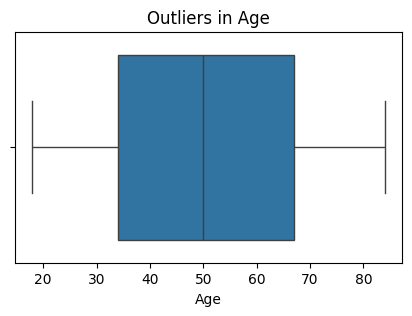

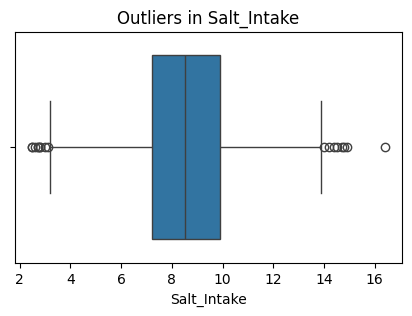

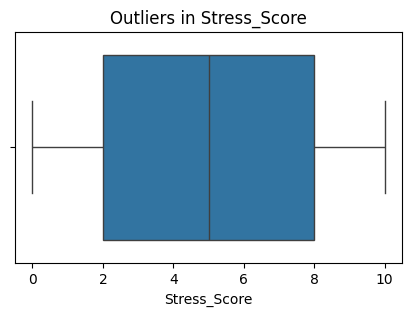

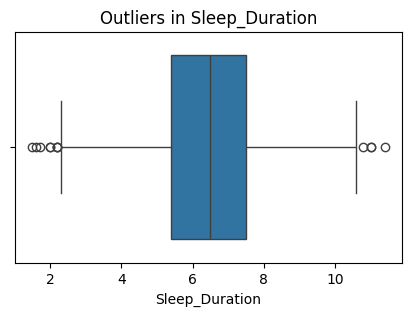

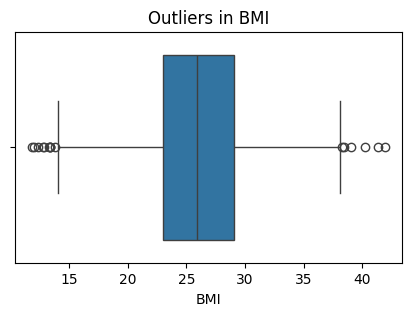

In [14]:
num_cols = data.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(f"Outliers in {col}")
    plt.show()


# MACHINE LEARNING

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = data.drop("Has_Hypertension_Yes", axis=1)
y = data["Has_Hypertension_Yes"]

# TRAINING DATA

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Training models

# 1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)



# 2. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


# 3. Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)


# MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

Logistic Regression Accuracy: 0.871536523929471
Random Forest Accuracy: 0.9496221662468514
SVM Accuracy: 0.8866498740554156


# Get Probability Scores

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_probs = lr.predict_proba(X_test_scaled)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]
svm_probs = svm.predict_proba(X_test_scaled)[:,1]


# ROC_CURVE

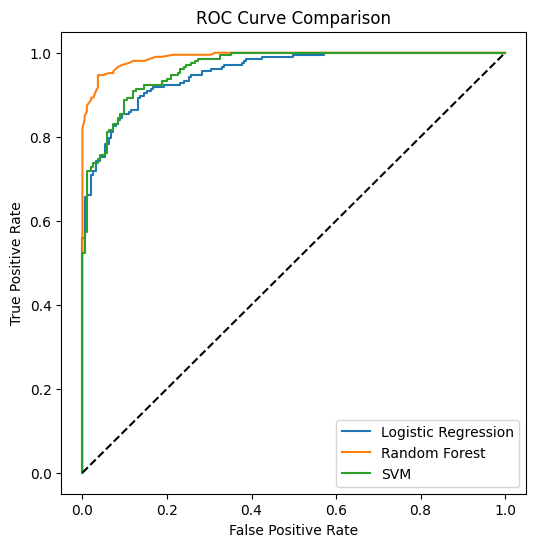

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# AUC Score

In [ ]:
print("LR AUC:", roc_auc_score(y_test, lr_probs))
print("RF AUC:", roc_auc_score(y_test, rf_probs))
print("SVM AUC:", roc_auc_score(y_test, svm_probs))


LR AUC: 0.9541757739033193
RF AUC: 0.9906216642098307
SVM AUC: 0.9635795252376353


# Precision-Recall Curve

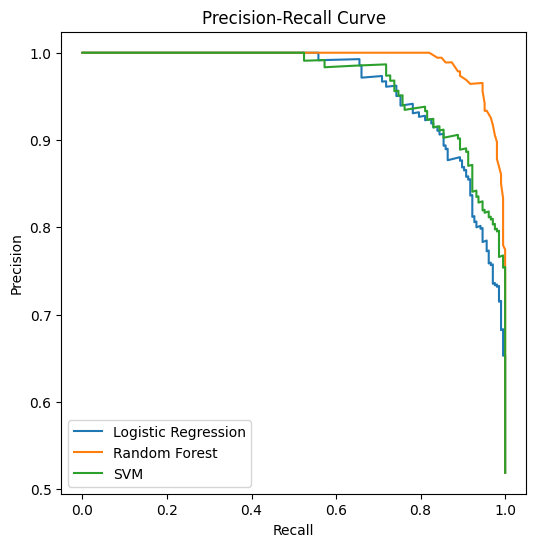

In [ ]:
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_probs)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_probs)
prec_svm, rec_svm, _ = precision_recall_curve(y_test, svm_probs)

plt.figure(figsize=(6,6))
plt.plot(rec_lr, prec_lr, label="Logistic Regression")
plt.plot(rec_rf, prec_rf, label="Random Forest")
plt.plot(rec_svm, prec_svm, label="SVM")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


# Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))


                       Feature  Importance
6   BP_History_Prehypertension    0.130242
0                          Age    0.129387
5            BP_History_Normal    0.127309
4                          BMI    0.111041
2                 Stress_Score    0.109061
1                  Salt_Intake    0.107558
3               Sleep_Duration    0.102564
10          Family_History_Yes    0.070439
13       Smoking_Status_Smoker    0.062193
11          Exercise_Level_Low    0.012040


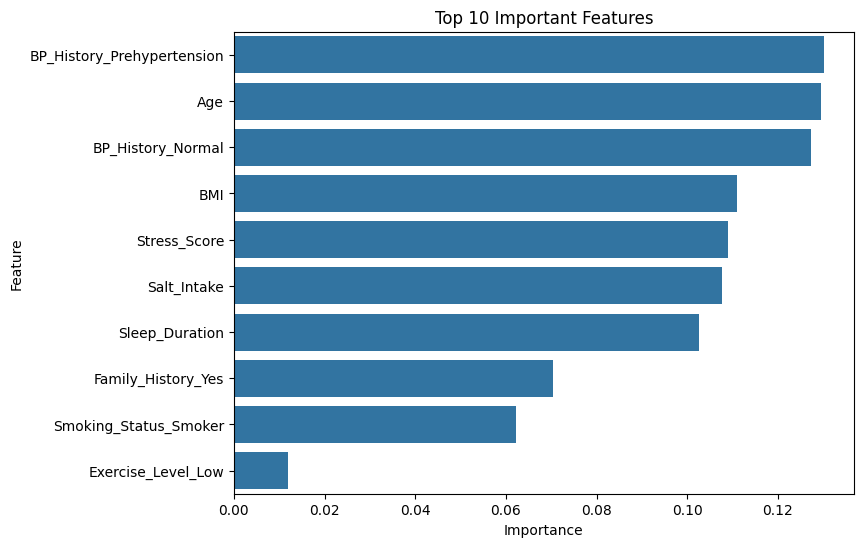

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.show()


# MODEL COMPARSION

In [ ]:
acc_lr = accuracy_score(y_test, lr_pred)
acc_rf = accuracy_score(y_test, rf_pred)
acc_svm = accuracy_score(y_test, svm_pred)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [acc_lr, acc_rf, acc_svm],
    "AUC Score": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, svm_probs)
    ]
})

print(comparison)


                 Model  Accuracy  AUC Score
0  Logistic Regression  0.871537   0.954176
1        Random Forest  0.949622   0.990622
2                  SVM  0.886650   0.963580


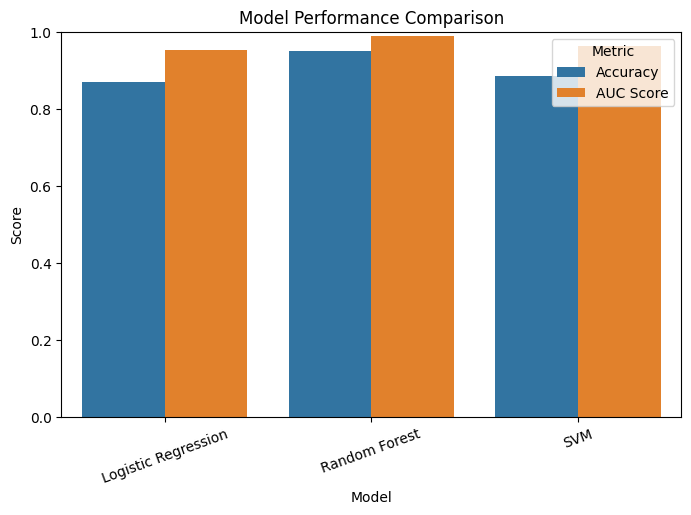

In [ ]:
comparison_model = comparison.melt(id_vars="Model", 
                                    var_name="Metric", 
                                    value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Score", hue="Metric", data=comparison_model)
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.show()


In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop("Has_Hypertension_Yes", axis=1)

import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(svm, "hypertension_model.pkl")
joblib.dump(scaler, "hypertension_scaler.pkl")

print("Model, scaler and feature list saved!")


Model, scaler and feature list saved!
